In [38]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"H:\Materias - Escola\PYTHON\Atividade5\Tabela4.csv"
df = pd.read_csv(path, sep=";", encoding='latin1', skiprows=1, decimal=",")


In [39]:
df = df.dropna(axis=1, how='all')

estados_ordem = df.sort_values(by='2024', ascending=False)

print(estados_ordem[['Estado', '2024']])

                 Estado   2024
6      Distrito Federal  0.866
25            São Paulo  0.838
23       Santa Catarina  0.833
17               Paraná  0.822
18       Rio de Janeiro  0.819
22    Rio Grande do Sul  0.818
8                 Goiás  0.815
12          Mato Grosso  0.812
10         Minas Gerais  0.809
7        Espírito Santo  0.804
26            Tocantins  0.797
11   Mato Grosso do Sul  0.797
20             Rondônia  0.786
21              Roraima  0.780
19  Rio Grande do Norte  0.778
5                 Ceará  0.773
2              Amazonas  0.767
15           Pernambuco  0.767
16                Piauí  0.764
24              Sergipe  0.761
14              Paraíba  0.760
4                 Bahia  0.759
3                 Amapá  0.759
13                 Pará  0.758
0                  Acre  0.754
1               Alagoas  0.746
9              Maranhão  0.745


In [40]:
df

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759
5,CE,23,Ceará,0.405,0.541,0.682,0.709,0.712,0.717,0.723,0.727,0.737,0.746,0.754,0.753,0.740,0.759,0.773,0.773
6,DF,53,Distrito Federal,0.616,0.725,0.824,0.824,0.834,0.834,0.833,0.842,0.842,0.845,0.860,0.837,0.823,0.867,0.870,0.866
7,ES,32,Espírito Santo,0.505,0.640,0.740,0.747,0.755,0.763,0.766,0.766,0.769,0.776,0.780,0.773,0.754,0.782,0.803,0.804
8,GO,52,Goiás,0.487,0.615,0.735,0.744,0.753,0.759,0.758,0.765,0.770,0.776,0.780,0.777,0.755,0.797,0.809,0.815
9,MA,21,Maranhão,0.357,0.476,0.639,0.669,0.682,0.683,0.690,0.698,0.704,0.706,0.715,0.715,0.701,0.730,0.740,0.745


In [60]:
df["diferença"] = df['2024'] - df['1991']

In [45]:
df["diferença"]


0     0.352
1     0.376
2     0.337
3     0.287
4     0.373
5     0.368
6     0.250
7     0.299
8     0.328
9     0.388
10    0.331
11    0.309
12    0.363
13    0.345
14    0.378
15    0.327
16    0.402
17    0.315
18    0.246
19    0.350
20    0.379
21    0.321
22    0.276
23    0.290
24    0.353
25    0.260
26    0.428
Name: diferença, dtype: float64

In [46]:
anos = [c for c in df.columns if str(c).isdigit()]
print(anos)

id_vars = [c for c in df.columns if c not in anos]
df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")
df_longo.head()


['1991', '2000', '2010', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


,Sigla,Código,Estado,diferença,Ano,IDH
0,AC,12,Acre,0.352,1991,0.402
1,AL,27,Alagoas,0.376,1991,0.370
2,AM,13,Amazonas,0.337,1991,0.430
3,AP,16,Amapá,0.287,1991,0.472
4,BA,29,Bahia,0.373,1991,0.386


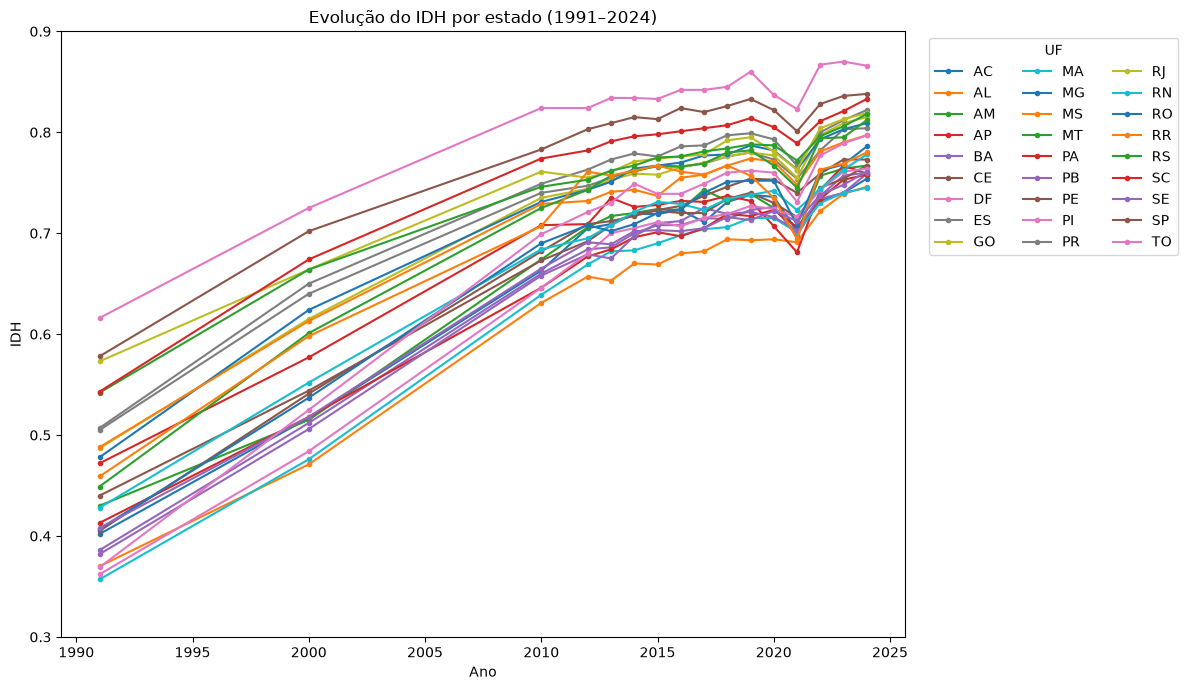

In [47]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()

In [51]:
df_longo_mg = df_longo[df_longo["Sigla"] == "MG"]

In [52]:
df_longo_mg

,Sigla,Código,Estado,diferença,Ano,IDH
10,MG,31,Minas Gerais,0.331,1991,0.478
37,MG,31,Minas Gerais,0.331,2000,0.624
64,MG,31,Minas Gerais,0.331,2010,0.731
91,MG,31,Minas Gerais,0.331,2012,0.743
118,MG,31,Minas Gerais,0.331,2013,0.751
145,MG,31,Minas Gerais,0.331,2014,0.764
172,MG,31,Minas Gerais,0.331,2015,0.767
199,MG,31,Minas Gerais,0.331,2016,0.770
226,MG,31,Minas Gerais,0.331,2017,0.777
253,MG,31,Minas Gerais,0.331,2018,0.778


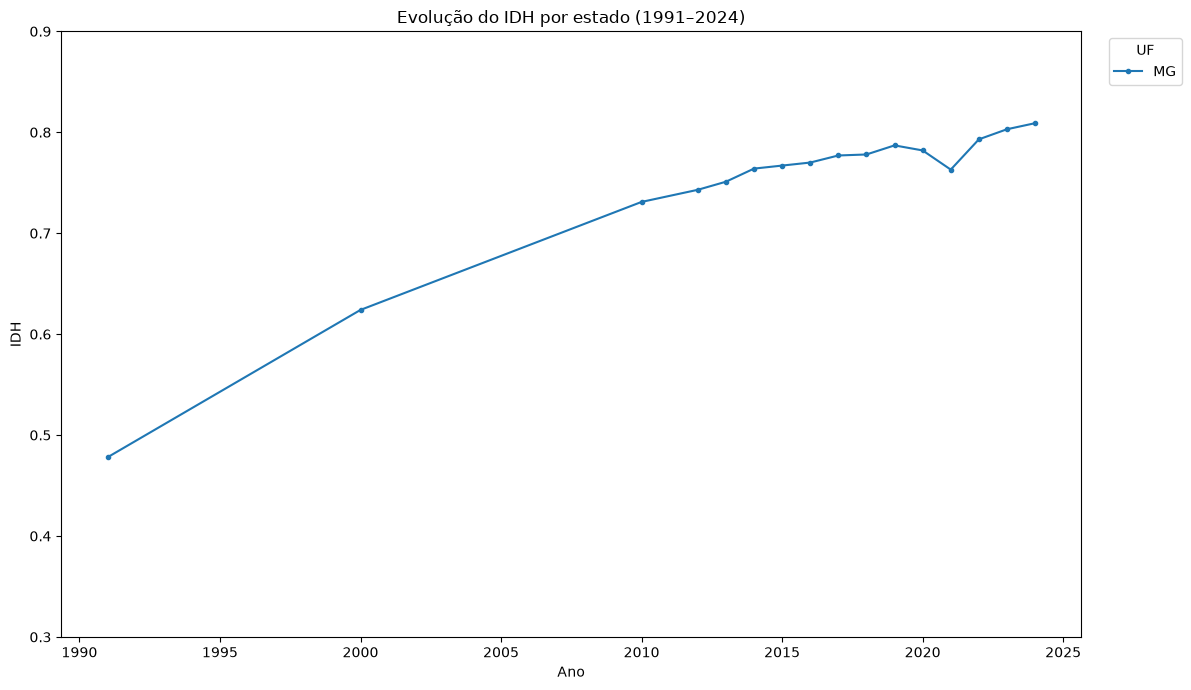

In [54]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo_mg.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()

In [59]:
df["diferença"] = df['2024'] - df['1991']

df_ordem = df.sort_values(by="diferença", ascending=False)

print(df_ordem[['Estado', '1991', '2024', 'diferença']])

                 Estado   1991   2024  diferença
26            Tocantins  0.369  0.797      0.428
16                Piauí  0.362  0.764      0.402
9              Maranhão  0.357  0.745      0.388
20             Rondônia  0.407  0.786      0.379
14              Paraíba  0.382  0.760      0.378
1               Alagoas  0.370  0.746      0.376
4                 Bahia  0.386  0.759      0.373
5                 Ceará  0.405  0.773      0.368
12          Mato Grosso  0.449  0.812      0.363
24              Sergipe  0.408  0.761      0.353
0                  Acre  0.402  0.754      0.352
19  Rio Grande do Norte  0.428  0.778      0.350
13                 Pará  0.413  0.758      0.345
2              Amazonas  0.430  0.767      0.337
10         Minas Gerais  0.478  0.809      0.331
8                 Goiás  0.487  0.815      0.328
15           Pernambuco  0.440  0.767      0.327
21              Roraima  0.459  0.780      0.321
17               Paraná  0.507  0.822      0.315
11   Mato Grosso do 

In [64]:
df["diferença"] = df['2024'] - df['1991']
piorou = df[df["diferença"] < 0]

if piorou.empty:
    print("Não, nenhum estado piorou o IDH entre 1991 e 2024. Todos apresentaram crescimento.")
else:
    print("Sim, os seguintes estados pioraram:")
    print(piorou[['Estado', '1991', '2024', 'diferença']])


Não, nenhum estado piorou o IDH entre 1991 e 2024. Todos apresentaram crescimento.


In [67]:
df_longo = df.melt(
    id_vars=['Estado'], 
    value_vars=['1991', '2024'], 
    var_name='Ano', 
    value_name='IDH'
)

df_longo['Ano'] = df_longo['Ano'].astype(int)

print(df_longo.head())


     Estado   Ano    IDH
0      Acre  1991  0.402
1   Alagoas  1991  0.370
2  Amazonas  1991  0.430
3     Amapá  1991  0.472
4     Bahia  1991  0.386


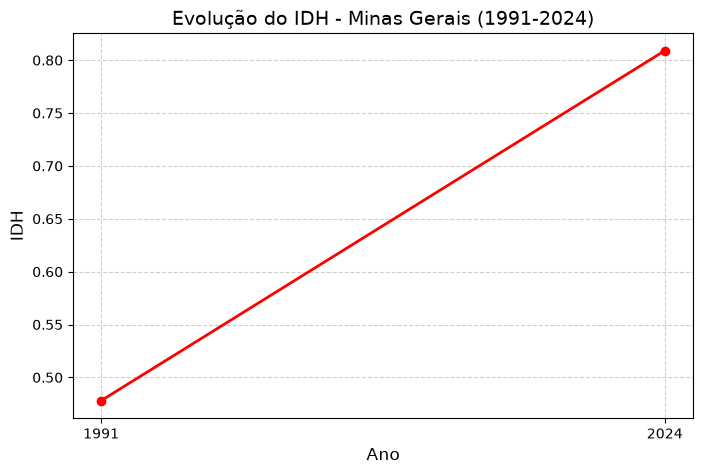

In [68]:
df_mg = df_longo[df_longo['Estado'] == 'Minas Gerais']

plt.figure(figsize=(8, 5))
plt.plot(df_mg['Ano'], df_mg['IDH'], marker='o', color='red', linewidth=2)

plt.title('Evolução do IDH - Minas Gerais (1991-2024)', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('IDH', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(df_mg['Ano'].unique()) 

plt.show()


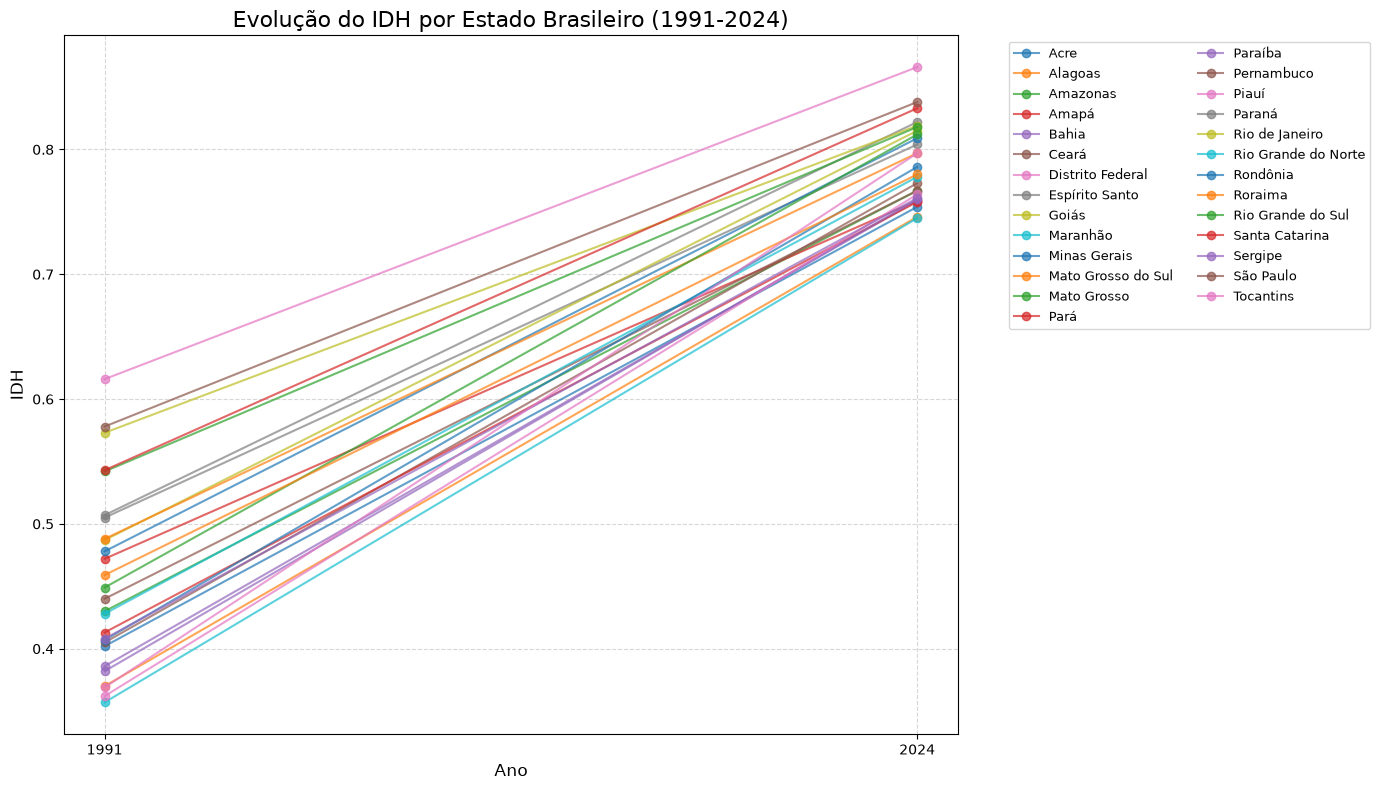

In [69]:
plt.figure(figsize=(14, 8))

for estado in df_longo['Estado'].unique():
    df_estado = df_longo[df_longo['Estado'] == estado]
    plt.plot(df_estado['Ano'], df_estado['IDH'], marker='o', label=estado, alpha=0.7)

plt.title('Evolução do IDH por Estado Brasileiro (1991-2024)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('IDH', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
plt.xticks(df_longo['Ano'].unique())

plt.tight_layout()
plt.show()
